In [43]:
# ABOUTME: Interactive notebook teaching binary classification thresholding
# ABOUTME: Uses a fever detection scenario to build intuition for TP/TN/FP/FN and ROC curves
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from ipywidgets import interact, widgets
%matplotlib widget

# Fever Detection: Drawing the Line Between Sick and Healthy

**Scenario:** You're the school nurse at a primary school. Every morning, you measure the temperature of 200 students. Your job: decide who is too sick to stay in class.

But where do you set the threshold?

- Too **low**, and you send healthy kids home for nothing. Parents are furious, the classroom is half-empty, and you look paranoid.
- Too **high**, and a sick kid stays in class, infects everyone, and suddenly you've got an epidemic on your hands.

This is the fundamental problem of **binary classification**: choosing a cutoff that separates two groups, knowing you'll inevitably make some mistakes. Let's explore what those mistakes look like and how to reason about them.

## Generating Our Data

We'll simulate a realistic school scenario:

- **Healthy students** have body temperatures centered around **36.8°C** with a standard deviation of ±0.4°C — most cluster tightly, but some naturally run a bit warm.
- **Sick students** have temperatures centered around **37.8°C** with a standard deviation of ±0.6°C — wider spread, because different illnesses cause different fever levels. Note that the mean is only **1°C higher** than healthy — many sick kids have a mild fever that overlaps heavily with healthy temperatures.
- There's a **large overlap zone** (roughly 36.5–38.5°C) where healthy and sick students have similar temperatures. This is where the problem gets genuinely hard — there is no clean line.
- **Class imbalance**: about **85% healthy** and **15% sick**. This is realistic — most kids are healthy on any given day. But as we'll see, this imbalance has sneaky consequences for our metrics.

In [44]:
np.random.seed(42)
n_healthy = 170
n_sick = 30

temps_healthy = np.random.normal(36.8, 0.4, n_healthy)
temps_sick = np.random.normal(37.8, 0.6, n_sick)

# Clip to realistic range
temps_healthy = np.clip(temps_healthy, 35.5, 40.0)
temps_sick = np.clip(temps_sick, 35.5, 41.0)

temperatures = np.concatenate([temps_healthy, temps_sick])
labels = np.concatenate([np.zeros(n_healthy), np.ones(n_sick)])

# Shuffle
shuffle_idx = np.random.permutation(len(temperatures))
temperatures = temperatures[shuffle_idx]
labels = labels[shuffle_idx]

print(f"Total students: {len(temperatures)}")
print(f"Healthy: {int((labels == 0).sum())} | Sick: {int((labels == 1).sum())}")
print(f"Temperature range: {temperatures.min():.1f}°C — {temperatures.max():.1f}°C")
print(f"Healthy mean: {temps_healthy.mean():.2f}°C | Sick mean: {temps_sick.mean():.2f}°C")

Total students: 200
Healthy: 170 | Sick: 30
Temperature range: 35.8°C — 39.4°C
Healthy mean: 36.78°C | Sick mean: 37.79°C


## What Does Our Data Look Like?

Let's plot each student's temperature. Blue dots are healthy kids, red dots are sick kids. Notice how the two groups overlap in the middle — that's the tricky zone where any threshold will make mistakes.

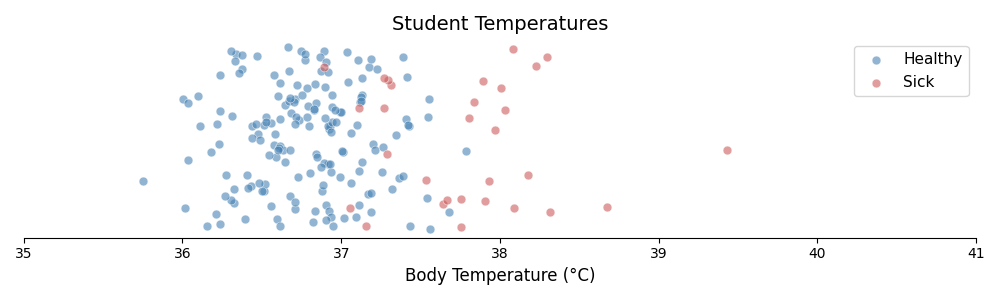

In [45]:
fig, ax = plt.subplots(figsize=(10, 3))

jitter_rng = np.random.RandomState(0)
jitter = jitter_rng.uniform(-0.3, 0.3, len(temperatures))

healthy_mask = labels == 0
sick_mask = labels == 1

ax.scatter(temperatures[healthy_mask], jitter[healthy_mask], 
           c='steelblue', alpha=0.6, s=40, label='Healthy', edgecolors='white', linewidth=0.5)
ax.scatter(temperatures[sick_mask], jitter[sick_mask], 
           c='indianred', alpha=0.6, s=40, label='Sick', edgecolors='white', linewidth=0.5)

ax.set_xlabel('Body Temperature (°C)', fontsize=12)
ax.set_yticks([])
ax.set_title('Student Temperatures', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(35, 41)
sns.despine(left=True)
plt.tight_layout()
plt.show()

## Drawing the Line

A **threshold** is a simple rule: if temperature ≥ threshold → predict **Sick**, otherwise → predict **Healthy**.

But every threshold makes trade-offs. Move the line left: you catch more sick kids, but also send more healthy kids home. Move it right: fewer false alarms, but some sick kids slip through.

## The Four Outcomes

When you make a prediction, exactly one of four things happens:

| | Actually Healthy | Actually Sick |
|---|---|---|
| **Predicted Healthy** | ✅ **True Negative (TN)** — Healthy kid stays in class. Everyone's happy. | ❌ **False Negative (FN)** — Sick kid stays and infects classmates! |
| **Predicted Sick** | ❌ **False Positive (FP)** — Healthy kid sent home for nothing. Annoyed parents call you. | ✅ **True Positive (TP)** — Sick kid sent home to rest. Good call! |

**False Positives** are annoying. **False Negatives** are dangerous.

In medicine, we often care more about False Negatives (missing a disease) than False Positives (a false alarm). But in spam filtering, a False Positive (a real email in your spam folder) might be worse than a False Negative (a spam email in your inbox). Context matters!

In [46]:
def classify_students(temperatures, threshold):
    """Predict sick (1) if temperature >= threshold, else healthy (0)."""
    return (temperatures >= threshold).astype(int)


def get_metrics(y_true, y_pred):
    """Compute classification metrics with zero-division protection."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

    return {
        'cm': cm, 'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
        'accuracy': accuracy, 'precision': precision,
        'recall': recall, 'f1': f1, 'fpr': fpr
    }

In [ ]:
fig_main, axes_dict = plt.subplot_mosaic(
    [['scatter', 'scatter'],
     ['cm', 'bar'],
     ['metrics', 'metrics']],
    figsize=(12, 10),
    height_ratios=[2, 2, 1.5],
    gridspec_kw={'hspace': 0.35, 'wspace': 0.3}
)

ax_scatter = axes_dict['scatter']
ax_cm      = axes_dict['cm']
ax_bar     = axes_dict['bar']
ax_metrics = axes_dict['metrics']

# Persistent suptitle — update text in place to avoid figure-level ghosting
title_text = fig_main.suptitle('', fontsize=14, fontweight='bold')

jitter_rng_main = np.random.RandomState(0)
jitter_main = jitter_rng_main.uniform(-0.3, 0.3, len(temperatures))

# Initialize the canvas buffer so ipympl diffs work from the first frame
fig_main.canvas.draw()


@interact(
    threshold=widgets.FloatSlider(
        min=35.5, max=40.5, step=0.1, value=37.5,
        description='Threshold °C:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px')
    )
)
def explore_threshold(threshold):
    ax_scatter.clear()
    ax_cm.clear()
    ax_bar.clear()
    ax_metrics.clear()

    y_pred = classify_students(temperatures, threshold)
    m = get_metrics(labels, y_pred)

    # --- Row 1: Scatter plot with threshold line ---
    ax_scatter.axvspan(35, threshold, alpha=0.1, color='steelblue')
    ax_scatter.axvspan(threshold, 41, alpha=0.1, color='indianred')
    ax_scatter.axvline(x=threshold, color='black', linestyle='--', linewidth=2,
                       label=f'Threshold = {threshold:.1f}°C')

    # Vectorized scatter: 4 calls instead of 200 per-point calls
    tn_mask = (labels == 0) & (y_pred == 0)
    tp_mask = (labels == 1) & (y_pred == 1)
    fp_mask = (labels == 0) & (y_pred == 1)
    fn_mask = (labels == 1) & (y_pred == 0)

    ax_scatter.scatter(temperatures[tn_mask], jitter_main[tn_mask], c='steelblue',
                       s=30, alpha=0.7, edgecolors='white', linewidth=0.3)
    ax_scatter.scatter(temperatures[tp_mask], jitter_main[tp_mask], c='forestgreen',
                       s=30, alpha=0.7, edgecolors='white', linewidth=0.3)
    ax_scatter.scatter(temperatures[fp_mask], jitter_main[fp_mask], c='orange',
                       s=30, alpha=0.7, edgecolors='white', linewidth=0.3)
    ax_scatter.scatter(temperatures[fn_mask], jitter_main[fn_mask], c='crimson',
                       s=30, alpha=0.7, edgecolors='white', linewidth=0.3)

    patches = [
        mpatches.Patch(color='steelblue', label=f'TN: {m["TN"]}'),
        mpatches.Patch(color='forestgreen', label=f'TP: {m["TP"]}'),
        mpatches.Patch(color='orange', label=f'FP: {m["FP"]}'),
        mpatches.Patch(color='crimson', label=f'FN: {m["FN"]}'),
    ]
    ax_scatter.legend(handles=patches, loc='upper left', fontsize=9)
    ax_scatter.set_xlabel('Temperature (°C)')
    ax_scatter.set_yticks([])
    ax_scatter.set_xlim(35, 41)
    ax_scatter.set_title('Students Classified by Threshold')

    # --- Row 2 Left: Confusion matrix heatmap ---
    sns.heatmap(m['cm'], annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Healthy', 'Sick'], yticklabels=['Healthy', 'Sick'],
                cbar=False, annot_kws={'size': 16})
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_title('Confusion Matrix')

    # --- Row 2 Right: Bar chart of outcome counts ---
    categories = ['TN\n(Correct\nHealthy)', 'TP\n(Correct\nSick)',
                  'FP\n(False\nAlarm)', 'FN\n(Missed\nSick)']
    values = [m['TN'], m['TP'], m['FP'], m['FN']]
    colors = ['steelblue', 'forestgreen', 'orange', 'crimson']
    bars = ax_bar.bar(categories, values, color=colors, edgecolor='white')
    for bar, val in zip(bars, values):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    str(val), ha='center', fontsize=11, fontweight='bold')
    ax_bar.set_ylabel('Count')
    ax_bar.set_title('Outcome Breakdown')
    ax_bar.set_ylim(0, max(values) + 10 if max(values) > 0 else 10)

    # --- Row 3: Metrics with formulas showing TP/TN/FP/FN substitution ---
    ax_metrics.axis('off')
    TP, TN, FP, FN = m['TP'], m['TN'], m['FP'], m['FN']
    total = TP + TN + FP + FN
    P, R = m['precision'], m['recall']
    PR_sum = P + R

    metrics_data = [
        ("Accuracy ", "(TP + TN) / (TP + TN + FP + FN)",
         f"({TP} + {TN}) / {total}",
         m['accuracy'], "overall correct"),
        ("Precision", "TP / (TP + FP)",
         f"{TP} / ({TP} + {FP})",
         m['precision'], "of flagged, how many sick?"),
        ("Recall   ", "TP / (TP + FN)",
         f"{TP} / ({TP} + {FN})",
         m['recall'], "of sick, how many caught?"),
        ("F1       ", "2·P·R / (P + R)",
         f"2·{P:.2f}·{R:.2f} / {PR_sum:.2f}",
         m['f1'], "balance of P and R"),
    ]

    for i, (name, formula, substituted, result, desc) in enumerate(metrics_data):
        y = 0.85 - i * 0.22
        line = f"{name} = {formula:<34s}= {substituted:<22s}= {result:>6.1%}   {desc}"
        ax_metrics.text(0.02, y, line, fontsize=9,
                        fontfamily='monospace', transform=ax_metrics.transAxes,
                        verticalalignment='top')
    ax_metrics.set_title('Metrics', fontsize=13)

    title_text.set_text(f'Threshold Explorer — {threshold:.1f}°C')
    fig_main.canvas.draw_idle()

## The Precision-Recall Trade-off

Play with the slider above and watch what happens:

- **Low threshold** (e.g., 36.0°C): You send almost everyone home. Very few sick kids are missed (**high recall**), but tons of healthy kids are sent home for nothing (**low precision**). The school is empty and parents are livid.

- **High threshold** (e.g., 39.0°C): You barely send anyone home. The ones you do send are truly sick (**high precision**), but many sick kids slip through and stay in class (**low recall**). There's a flu outbreak by Friday.

- **In between** (around 37.0–37.5°C): No threshold feels great. Because the distributions overlap so much, every choice is a real compromise — you'll always misclassify some students. That's the point!

**You can't have it all. This is the fundamental tension in classification.** The "right" threshold depends on the cost of each type of mistake — and that's a *domain* question, not a math question.

## The Formulas

$$\text{Precision} = \frac{TP}{TP + FP}$$

"Of everyone I *flagged as sick*, how many are *actually* sick?"

$$\text{Recall} = \frac{TP}{TP + FN}$$

"Of everyone who *is actually sick*, how many did I *catch*?"

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

"Overall, how often am I right?"

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

"A single number that balances Precision and Recall (harmonic mean — it punishes you if *either* one is low)."

## The Accuracy Paradox

Only 15% of our students are sick. What if we just predicted *everyone is healthy*?

We'd be right **85% of the time**! Sounds great... except we'd miss **every single sick kid**.

This is why accuracy alone is a terrible metric for imbalanced datasets. A model that does *literally nothing* can score 85% accuracy. Always ask yourself: *"What would a dumb baseline achieve?"*

In [48]:
# The "lazy nurse" strategy: predict everyone as healthy
y_pred_lazy = np.zeros_like(labels)
m_lazy = get_metrics(labels, y_pred_lazy)

print("The Lazy Nurse Strategy: 'Nobody is sick!'")
print("=" * 50)
print(f"  Accuracy:  {m_lazy['accuracy']:.1%}  ← Looks great!")
print(f"  Precision: {m_lazy['precision']:.1%}  ← No predictions made")
print(f"  Recall:    {m_lazy['recall']:.1%}  ← Missed EVERY sick student!")
print(f"  F1 Score:  {m_lazy['f1']:.1%}  ← Terrible, as it should be")
print()
print(f"  Sick students missed: {int(m_lazy['FN'])} out of {int(labels.sum())}")
print()
print("Lesson: Always ask 'What would a dumb baseline achieve?'")

The Lazy Nurse Strategy: 'Nobody is sick!'
  Accuracy:  85.0%  ← Looks great!
  Precision: 0.0%  ← No predictions made
  Recall:    0.0%  ← Missed EVERY sick student!
  F1 Score:  0.0%  ← Terrible, as it should be

  Sick students missed: 30 out of 30

Lesson: Always ask 'What would a dumb baseline achieve?'


## From Threshold to ROC Curve

Each threshold gives us a pair of numbers: the **True Positive Rate** (Recall) and the **False Positive Rate**.

$$\text{TPR} = \text{Recall} = \frac{TP}{TP + FN}$$

$$\text{FPR} = \frac{FP}{FP + TN}$$

If we try *every possible threshold* and plot (FPR, TPR), we get the **ROC curve** (Receiver Operating Characteristic).

- A **perfect classifier** hugs the top-left corner (FPR=0, TPR=1).
- A **random coin flip** follows the diagonal.
- The area under the curve (**AUC**) summarizes overall performance: 1.0 = perfect, 0.5 = random.

/tmp/ipykernel_678043/4101896997.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig_roc, (ax_scatter_roc, ax_roc) = plt.subplots(1, 2, figsize=(12, 4.5))


interactive(children=(FloatSlider(value=37.5, description='Threshold °C:', layout=Layout(width='500px'), max=4…

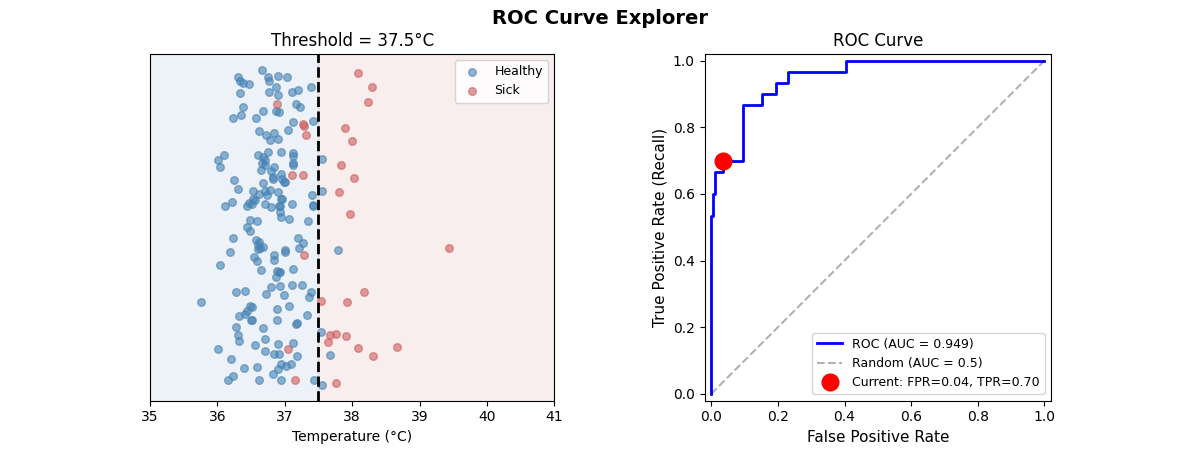

In [49]:
fig_roc, (ax_scatter_roc, ax_roc) = plt.subplots(1, 2, figsize=(12, 4.5))
fig_roc.subplots_adjust(wspace=0.3)

# Pre-compute ROC curve
fpr_curve, tpr_curve, thresholds_roc = roc_curve(labels, temperatures)
roc_auc = auc(fpr_curve, tpr_curve)

jitter_rng_roc = np.random.RandomState(0)
jitter_roc = jitter_rng_roc.uniform(-0.3, 0.3, len(temperatures))


@interact(
    threshold=widgets.FloatSlider(
        min=35.5, max=40.5, step=0.1, value=37.5,
        description='Threshold °C:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px')
    )
)
def explore_roc(threshold):
    ax_scatter_roc.clear()
    ax_roc.clear()

    y_pred = classify_students(temperatures, threshold)
    m = get_metrics(labels, y_pred)

    # Left panel: scatter with threshold
    ax_scatter_roc.axvspan(35, threshold, alpha=0.1, color='steelblue')
    ax_scatter_roc.axvspan(threshold, 41, alpha=0.1, color='indianred')
    ax_scatter_roc.axvline(x=threshold, color='black', linestyle='--', linewidth=2)

    healthy_mask = labels == 0
    sick_mask = labels == 1
    ax_scatter_roc.scatter(temperatures[healthy_mask], jitter_roc[healthy_mask],
                           c='steelblue', alpha=0.6, s=30, label='Healthy')
    ax_scatter_roc.scatter(temperatures[sick_mask], jitter_roc[sick_mask],
                           c='indianred', alpha=0.6, s=30, label='Sick')
    ax_scatter_roc.set_xlabel('Temperature (°C)')
    ax_scatter_roc.set_yticks([])
    ax_scatter_roc.set_xlim(35, 41)
    ax_scatter_roc.set_title(f'Threshold = {threshold:.1f}°C')
    ax_scatter_roc.legend(fontsize=9)

    # Right panel: ROC curve with moving dot
    ax_roc.plot(fpr_curve, tpr_curve, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.5)')
    ax_roc.plot(m['fpr'], m['recall'], 'ro', markersize=12, zorder=5,
               label=f'Current: FPR={m["fpr"]:.2f}, TPR={m["recall"]:.2f}')
    ax_roc.set_xlabel('False Positive Rate', fontsize=11)
    ax_roc.set_ylabel('True Positive Rate (Recall)', fontsize=11)
    ax_roc.set_title('ROC Curve')
    ax_roc.legend(loc='lower right', fontsize=9)
    ax_roc.set_xlim(-0.02, 1.02)
    ax_roc.set_ylim(-0.02, 1.02)
    ax_roc.set_aspect('equal')

    fig_roc.suptitle('ROC Curve Explorer', fontsize=14, fontweight='bold')
    fig_roc.canvas.draw_idle()

## Summary

- A **threshold** turns continuous values into binary predictions.
- Every threshold makes trade-offs between **precision** (don't cry wolf) and **recall** (don't miss the real wolves).
- **Accuracy** can be misleading with imbalanced data — always check precision and recall.
- The **ROC curve** shows performance across all thresholds at once.
- The **AUC** (Area Under the Curve) summarizes it in a single number: 1.0 = perfect, 0.5 = random.

**What's next?** In the real world, we don't pick the threshold by hand. Algorithms like **logistic regression** learn it from the data automatically. But understanding what happens under the hood — the trade-offs, the pitfalls, the metrics — will make you a better data scientist. When someone hands you an F1 score, you'll know exactly what it means and what it's hiding.